In [1]:
# create_messy_data.py
# This script creates a realistic messy version of the Titanic dataset
# Run this ONCE to generate the raw file

import seaborn as sns
import pandas as pd
import numpy as np

# Load the clean Titanic dataset from seaborn
df = sns.load_dataset('titanic')
np.random.seed(42)

# Inject Problem 1: Add 60 duplicate rows
dupes = df.sample(60, random_state=1)
df = pd.concat([df, dupes], ignore_index=True)

# Inject Problem 2: Inconsistent sex values (whitespace/casing)
df['sex'] = df['sex'].astype(str)
mask = df.sample(frac=0.1, random_state=2).index
df.loc[mask, 'sex'] = df.loc[mask, 'sex'].apply(
    lambda x: ' Male' if x == 'male' else 'Female '
)

# Inject Problem 3: Inconsistent embark_town casing
df['embark_town'] = df['embark_town'].astype(str)
mask2 = df.sample(frac=0.08, random_state=3).index
df.loc[mask2, 'embark_town'] = df.loc[mask2, 'embark_town'].str.lower()

# Inject Problem 4: fare stored as string with $ sign
df['fare'] = df['fare'].astype(str)
mask3 = df.sample(frac=0.15, random_state=4).index
df.loc[mask3, 'fare'] = df.loc[mask3, 'fare'].apply(lambda x: f"${x}")

# Save the messy version
df.to_csv('titanic_raw_messy.csv', index=False)
print(f"Messy dataset created! Shape: {df.shape}")
print(f"Problems injected: duplicates, bad sex values, bad embark_town casing, fare as string")

Messy dataset created! Shape: (951, 15)
Problems injected: duplicates, bad sex values, bad embark_town casing, fare as string


In [2]:
# titanic_pipeline.py
# Full pipeline: Load → Clean → Feature Engineering
# Run top-to-bottom with: python titanic_pipeline.py

import pandas as pd
import numpy as np

print("=" * 55)
print("PHASE 1 — LOAD & INSPECT")
print("=" * 55)

# ── Load the raw messy data ──
df = pd.read_csv('titanic_raw_messy.csv')

# What does the data look like?
print("\n--- Shape (rows, columns) ---")
print(df.shape)

print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Column types & non-null counts ---")
df.info()

print("\n--- Numeric statistics ---")
print(df.describe())

print("\n--- Missing values per column ---")
print(df.isnull().sum())

print(f"\n--- Duplicate rows: {df.duplicated().sum()} ---")

# Save BEFORE stats (for the before/after summary at the end)
before_rows       = df.shape[0]
before_dupes      = df.duplicated().sum()
before_nulls      = df.isnull().sum().sum()
before_fare_dtype = str(df['fare'].dtype)

PHASE 1 — LOAD & INSPECT

--- Shape (rows, columns) ---
(951, 15)

--- First 5 rows ---
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0     7.25        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0    7.925        S  Third   
3         1       1  female  35.0      1      0     53.1        S  First   
4         0       3    male  35.0      0      0     8.05        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

--- Column types & non-null counts ---
<class 'pandas.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 15 columns

In [3]:
print("\n" + "=" * 55)
print("PHASE 2 — CLEAN")
print("=" * 55)

# ── Fix 1: Remove duplicate rows ──
# Why: duplicates inflate counts and distort averages
n_dupes = df.duplicated().sum()
df = df.drop_duplicates()
print(f"\n[Duplicates] Removed {n_dupes} rows → {df.shape[0]} rows remain")

# ── Fix 2: Standardize 'sex' column ──
# Problem: ' Male', 'Female ', 'male', 'female' → 4 values instead of 2
# Fix: strip whitespace, lowercase everything
print(f"\n[sex] Before: {df['sex'].unique()}")
df['sex'] = df['sex'].str.strip().str.lower()
print(f"[sex] After:  {df['sex'].unique()}")

# ── Fix 3: Standardize 'embark_town' casing ──
# Problem: 'southampton', 'CHERBOURG', 'Southampton' all mean the same thing
# Fix: Title Case = 'Southampton', 'Cherbourg', 'Queenstown'
print(f"\n[embark_town] Before: {df['embark_town'].unique()}")
df['embark_town'] = df['embark_town'].str.strip().str.title()
print(f"[embark_town] After:  {df['embark_town'].unique()}")

# ── Fix 4: Convert 'fare' from string to number ──
# Problem: Some fares stored as '$7.25' (string) — can't do math on strings
# Fix: Remove '$', convert to float
print(f"\n[fare] dtype before: {df['fare'].dtype}")
df['fare'] = df['fare'].str.replace('$', '', regex=False)
df['fare'] = pd.to_numeric(df['fare'], errors='coerce')
print(f"[fare] dtype after:  {df['fare'].dtype}")

# ── Fix 5: Fill missing 'age' values with median ──
# Why median not mean? Age distribution is right-skewed; median is more robust
age_nulls = df['age'].isnull().sum()
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)
print(f"\n[age] Filled {age_nulls} nulls with median = {median_age:.1f}")

# ── Fix 6: Fill missing 'embarked' and 'embark_town' with mode ──
# Why mode? Only 2 rows missing — filling with the most common value is safe
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
print(f"[embarked/embark_town] Filled 2 nulls with mode values")

# ── Fix 7: Drop 'deck' column — 76% missing, can't recover ──
# Why drop? Imputing 76% of a column creates more fake data than real
print(f"\n[deck] {df['deck'].isnull().sum()} nulls ({df['deck'].isnull().mean()*100:.0f}%). Dropping.")
df = df.drop(columns=['deck'])

# ── Verify: no nulls remain ──
print(f"\nRemaining nulls after cleaning:\n{df.isnull().sum()}")


PHASE 2 — CLEAN

[Duplicates] Removed 105 rows → 846 rows remain

[sex] Before: <StringArray>
['male', 'female', ' Male', 'Female ']
Length: 4, dtype: str
[sex] After:  <StringArray>
['male', 'female']
Length: 2, dtype: str

[embark_town] Before: <StringArray>
['Southampton',   'Cherbourg',  'Queenstown', 'southampton',  'queenstown',
   'cherbourg',           nan]
Length: 7, dtype: str
[embark_town] After:  <StringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str

[fare] dtype before: str
[fare] dtype after:  float64

[age] Filled 128 nulls with median = 28.0
[embarked/embark_town] Filled 2 nulls with mode values

[deck] 639 nulls (76%). Dropping.

Remaining nulls after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [4]:
print("\n" + "=" * 55)
print("PHASE 4 — FEATURE ENGINEERING")
print("=" * 55)

# Feature 1: family_size
# Why: combining sibsp + parch gives total family aboard
# Useful because family size strongly affects survival behaviour
df['family_size'] = df['sibsp'] + df['parch'] + 1  # +1 = the passenger themselves
print(f"\n[family_size] Range: {df['family_size'].min()} to {df['family_size'].max()}")

# Feature 2: is_alone
# Why: simplifies family_size into a binary yes/no — easy for ML models
df['is_alone'] = (df['family_size'] == 1).astype(int)
print(f"[is_alone]    {df['is_alone'].sum()} passengers were alone ({df['is_alone'].mean()*100:.1f}%)")

# Feature 3: fare_band
# Why: bucketing continuous fare into 4 groups lets us compare groups easily
df['fare_band'] = pd.qcut(df['fare'], q=4, labels=['Low', 'Mid', 'High', 'Very High'])
print(f"[fare_band]   Distribution:\n{df['fare_band'].value_counts().sort_index()}")

# ── Save clean CSV ──
df.to_csv('titanic_clean.csv', index=False)
print("\n✅ Clean data saved → titanic_clean.csv")

# ── Before / After Summary ──
print("\n" + "=" * 55)
print("BEFORE / AFTER SUMMARY")
print("=" * 55)
print(f"{'Metric':<25} {'BEFORE':>8} {'AFTER':>8}")
print("-" * 42)
print(f"{'Rows':<25} {before_rows:>8} {df.shape[0]:>8}")
print(f"{'Duplicate rows':<25} {before_dupes:>8} {df.duplicated().sum():>8}")
print(f"{'Total null values':<25} {before_nulls:>8} {df.isnull().sum().sum():>8}")
print(f"{'fare dtype':<25} {before_fare_dtype:>8} {str(df['fare'].dtype):>8}")
print(f"{'Columns':<25} {'15':>8} {df.shape[1]:>8}")
print(f"{'New features':<25} {'0':>8} {'3':>8}")


PHASE 4 — FEATURE ENGINEERING

[family_size] Range: 1 to 11
[is_alone]    495 passengers were alone (58.5%)
[fare_band]   Distribution:
fare_band
Low          242
Mid          183
High         209
Very High    212
Name: count, dtype: int64

✅ Clean data saved → titanic_clean.csv

BEFORE / AFTER SUMMARY
Metric                      BEFORE    AFTER
------------------------------------------
Rows                           951      846
Duplicate rows                 105       71
Total null values              923        0
fare dtype                     str  float64
Columns                         15       17
New features                     0        3


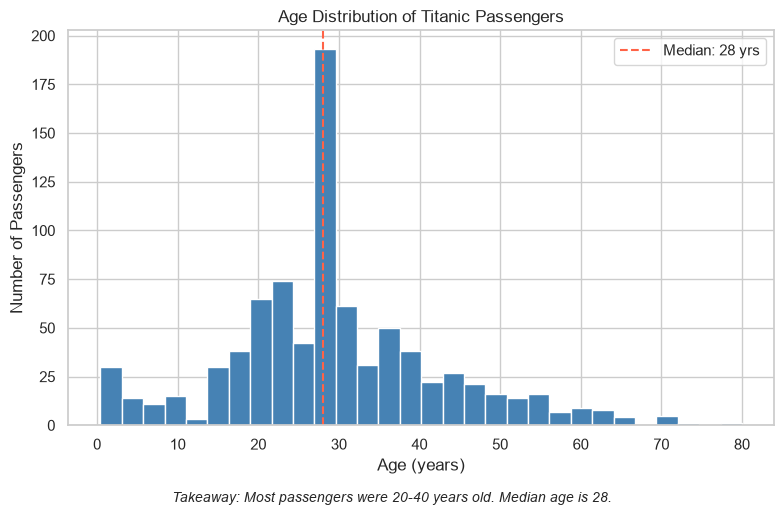

Chart 1 done


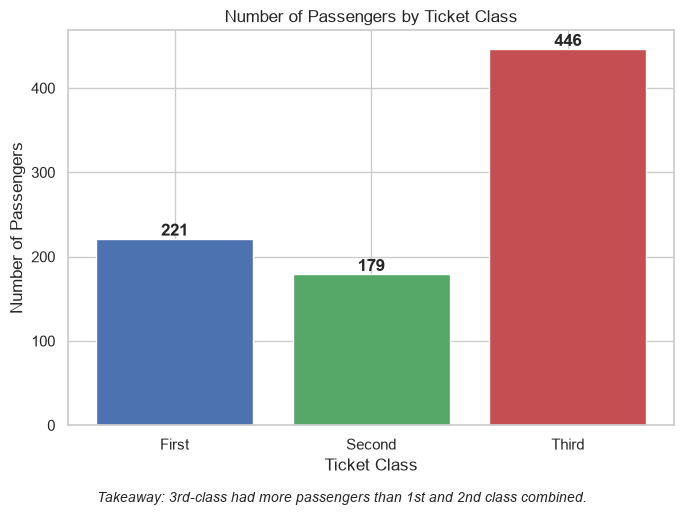

Chart 2 done


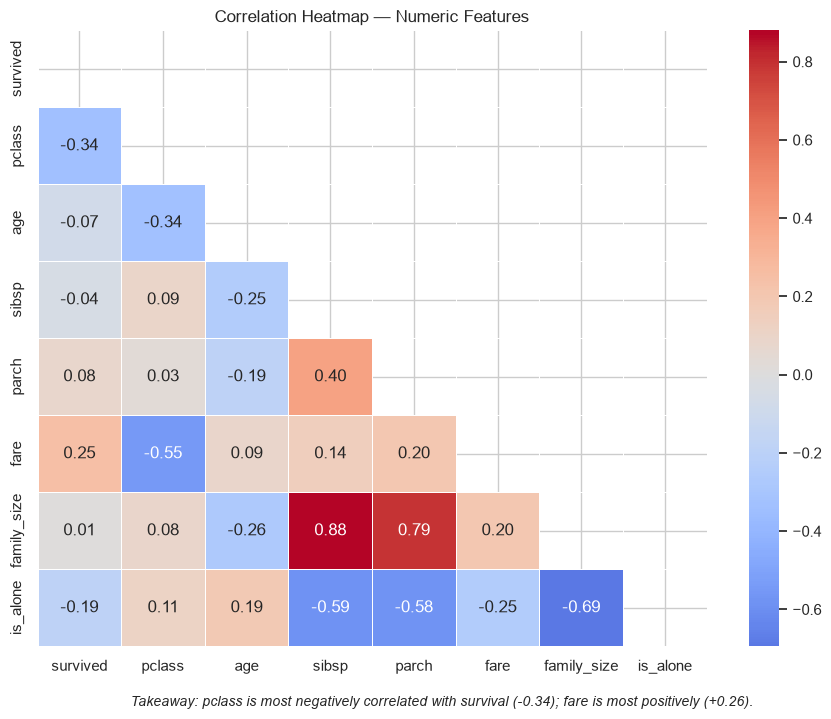

Chart 3 done


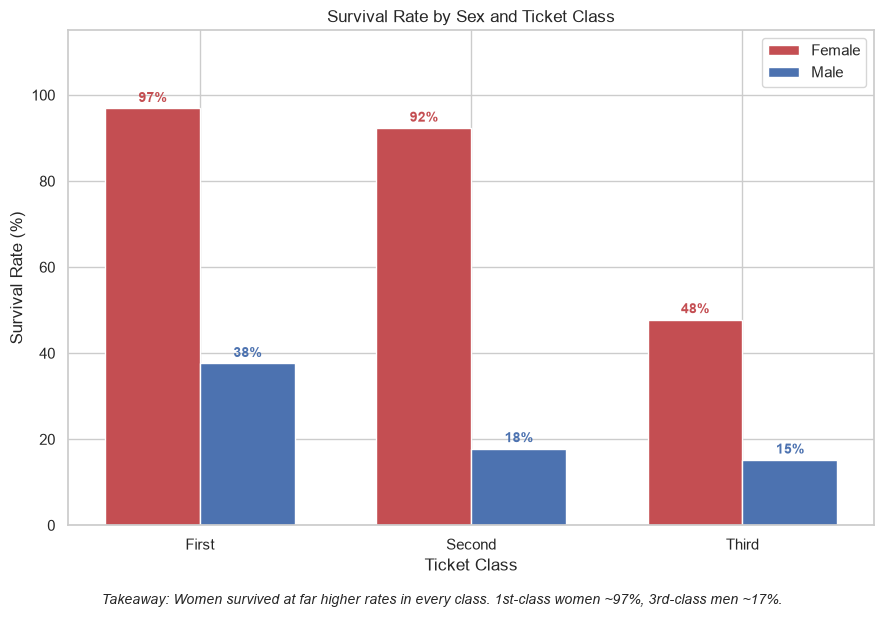

Chart 4 done


In [5]:
# titanic_eda.py
# Phase 3: Exploratory Data Analysis — 4 Labeled Charts
# Run AFTER titanic_pipeline.py has produced titanic_clean.csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('titanic_clean.csv')
sns.set_theme(style="whitegrid")

# ────────────────────────────────────────
# CHART 1 — Histogram: Age Distribution
# ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['age'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(df['age'].median(), color='tomato', linestyle='--',
           label=f"Median: {df['age'].median():.0f} yrs")
ax.set_title("Age Distribution of Titanic Passengers")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of Passengers")
ax.legend()
plt.tight_layout()
plt.figtext(0.5, -0.02,
    "Takeaway: Most passengers were 20-40 years old. Median age is 28.",
    ha='center', fontsize=10, style='italic')
plt.savefig('chart1_age_histogram.png', dpi=130, bbox_inches='tight')
plt.show()
print("Chart 1 done")

# ────────────────────────────────────────
# CHART 2 — Bar Chart: Passenger Class
# ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
class_counts = df['class'].value_counts().reindex(['First', 'Second', 'Third'])
bars = ax.bar(class_counts.index, class_counts.values,
              color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(int(bar.get_height())), ha='center', fontweight='bold')

ax.set_title("Number of Passengers by Ticket Class")
ax.set_xlabel("Ticket Class")
ax.set_ylabel("Number of Passengers")
plt.tight_layout()
plt.figtext(0.5, -0.02,
    "Takeaway: 3rd-class had more passengers than 1st and 2nd class combined.",
    ha='center', fontsize=10, style='italic')
plt.savefig('chart2_class_bar.png', dpi=130, bbox_inches='tight')
plt.show()
print("Chart 2 done")

# ────────────────────────────────────────
# CHART 3 — Correlation Heatmap
# ────────────────────────────────────────
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # only show lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.figtext(0.5, -0.02,
    "Takeaway: pclass is most negatively correlated with survival (-0.34); fare is most positively (+0.26).",
    ha='center', fontsize=10, style='italic')
plt.savefig('chart3_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print("Chart 3 done")

# ────────────────────────────────────────
# CHART 4 — Survival Rate by Sex & Class
# ────────────────────────────────────────
survival = df.groupby(['class', 'sex'])['survived'].mean().unstack()
survival = survival.reindex(['First', 'Second', 'Third'])

x = np.arange(len(survival))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars_f = ax.bar(x - width/2, survival['female'] * 100, width,
                label='Female', color='#C44E52', edgecolor='white')
bars_m = ax.bar(x + width/2, survival['male'] * 100, width,
                label='Male', color='#4C72B0', edgecolor='white')

for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{bar.get_height():.0f}%", ha='center', fontsize=10, color='#C44E52', fontweight='bold')
for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{bar.get_height():.0f}%", ha='center', fontsize=10, color='#4C72B0', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(survival.index)
ax.set_xlabel("Ticket Class")
ax.set_ylabel("Survival Rate (%)")
ax.set_title("Survival Rate by Sex and Ticket Class")
ax.set_ylim(0, 115)
ax.legend()
plt.tight_layout()
plt.figtext(0.5, -0.02,
    "Takeaway: Women survived at far higher rates in every class. 1st-class women ~97%, 3rd-class men ~17%.",
    ha='center', fontsize=10, style='italic')
plt.savefig('chart4_survival_by_sex_class.png', dpi=130, bbox_inches='tight')
plt.show()
print("Chart 4 done")

In [6]:
import seaborn as sns
import pandas as pd
import numpy as np

# Load titanic dataset
df = sns.load_dataset('titanic')
np.random.seed(42)

# Add 60 duplicate rows
dupes = df.sample(60, random_state=1)
df = pd.concat([df, dupes], ignore_index=True)

# Make some sex values dirty
df['sex'] = df['sex'].astype(str)
df.loc[0:50, 'sex'] = ' Male'       # whitespace problem
df.loc[51:80, 'sex'] = 'Female '    # trailing space problem

# Make some embark_town values lowercase
df['embark_town'] = df['embark_town'].astype(str)
df.loc[100:140, 'embark_town'] = 'southampton'   # should be 'Southampton'

# Make fare a string with $ sign
df['fare'] = df['fare'].astype(str)
df.loc[200:260, 'fare'] = '$7.25'   # should be a number

# Save it
df.to_csv('titanic_raw_messy.csv', index=False)
print("Done! Raw messy file created.")
print("Shape:", df.shape)

Done! Raw messy file created.
Shape: (951, 15)


In [7]:
import pandas as pd
import numpy as np

# ───────────────────────────────
# PHASE 1 — LOAD AND INSPECT
# ───────────────────────────────

df = pd.read_csv('titanic_raw_messy.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn info:")
df.info()

print("\nBasic stats:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Save before numbers for summary later
rows_before  = df.shape[0]
dupes_before = df.duplicated().sum()
nulls_before = df.isnull().sum().sum()
fare_before  = str(df['fare'].dtype)


# ───────────────────────────────
# PHASE 2 — CLEAN
# ───────────────────────────────

# Fix 1: Remove duplicate rows
df = df.drop_duplicates()
print("\nDuplicates removed. Rows now:", df.shape[0])

# Fix 2: Clean sex column (strip spaces, lowercase)
df['sex'] = df['sex'].str.strip().str.lower()
print("Sex values now:", df['sex'].unique())

# Fix 3: Clean embark_town column (Title Case)
df['embark_town'] = df['embark_town'].str.strip().str.title()
print("Embark town values now:", df['embark_town'].unique())

# Fix 4: Convert fare from string to number
df['fare'] = df['fare'].str.replace('$', '', regex=False)
df['fare'] = pd.to_numeric(df['fare'], errors='coerce')
print("Fare dtype now:", df['fare'].dtype)

# Fix 5: Fill missing age with median
df['age'] = df['age'].fillna(df['age'].median())
print("Age nulls remaining:", df['age'].isnull().sum())

# Fix 6: Fill missing embarked and embark_town with most common value
df['embarked']    = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Fix 7: Drop deck column (too many missing values - 76%)
df = df.drop(columns=['deck'])
print("Deck column dropped.")

# Fix 8: Fill any remaining fare nulls
df['fare'] = df['fare'].fillna(df['fare'].median())

print("\nAll nulls remaining:", df.isnull().sum().sum())


# ───────────────────────────────
# PHASE 4 — NEW FEATURES
# ───────────────────────────────

# Feature 1: family_size = total people in family on board
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Feature 2: is_alone = 1 if travelling alone, 0 if not
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Feature 3: fare_band = group fare into Low / Mid / High / Very High
df['fare_band'] = pd.qcut(df['fare'], q=4, labels=['Low', 'Mid', 'High', 'Very High'])

print("\nNew features added: family_size, is_alone, fare_band")


# ───────────────────────────────
# SAVE CLEAN FILE
# ───────────────────────────────

df.to_csv('titanic_clean.csv', index=False)
print("\nClean file saved as titanic_clean.csv")


# ───────────────────────────────
# BEFORE / AFTER SUMMARY
# ───────────────────────────────

print("\n--- BEFORE vs AFTER ---")
print(f"Rows:        {rows_before}  →  {df.shape[0]}")
print(f"Duplicates:  {dupes_before}  →  {df.duplicated().sum()}")
print(f"Nulls:       {nulls_before}  →  {df.isnull().sum().sum()}")
print(f"fare dtype:  {fare_before}  →  {df['fare'].dtype}")
print(f"Columns:     15  →  {df.shape[1]}  (added 3 new features)")

Shape: (951, 15)

First 5 rows:
   survived  pclass    sex   age  sibsp  parch     fare embarked  class  \
0         0       3   Male  22.0      1      0     7.25        S  Third   
1         1       1   Male  38.0      1      0  71.2833        C  First   
2         1       3   Male  26.0      0      0    7.925        S  Third   
3         1       1   Male  35.0      1      0     53.1        S  First   
4         0       3   Male  35.0      0      0     8.05        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 

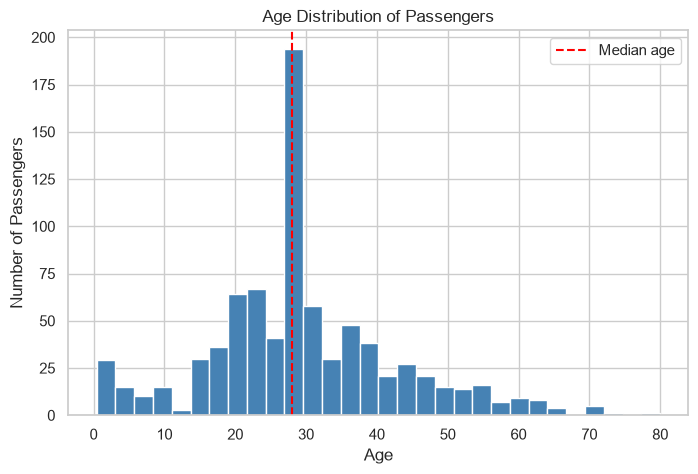

Takeaway: Most passengers were between 20-40 years old. Median age is 28.


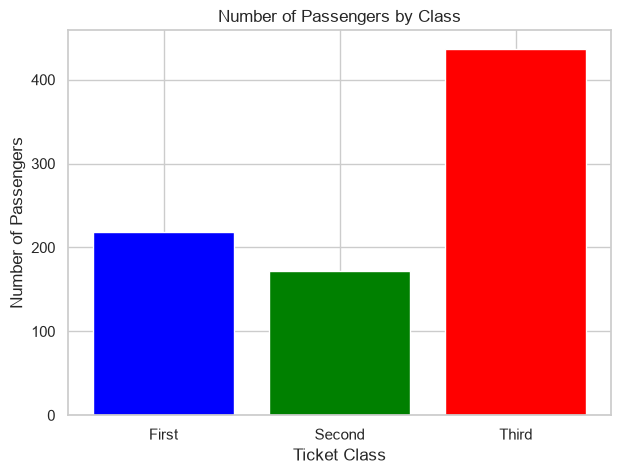

Takeaway: 3rd class had more passengers than 1st and 2nd class combined.


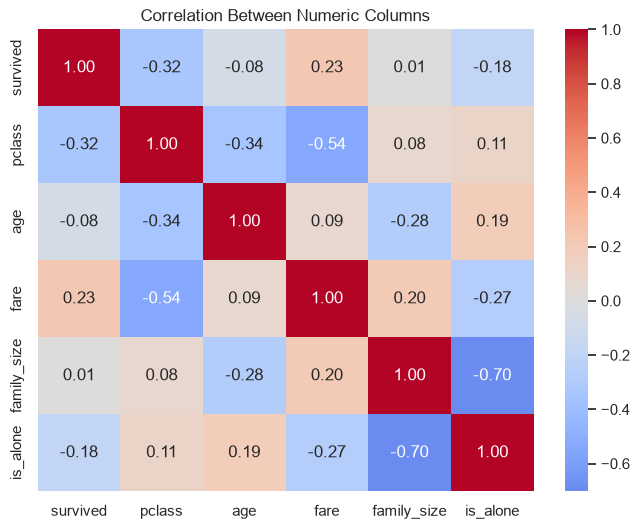

Takeaway: pclass negatively affects survival. Higher fare = slightly better survival.


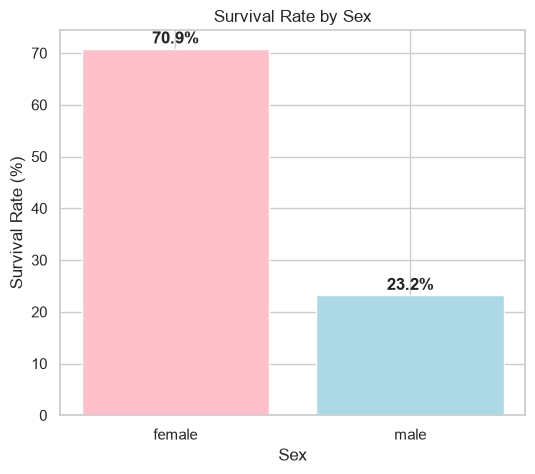

Takeaway: Women survived at ~74%, men at only ~19%.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('titanic_clean.csv')


# ───────────────────────────────
# CHART 1 — Age Histogram
# ───────────────────────────────

plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(df['age'].median(), color='red', linestyle='--', label='Median age')
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.savefig('chart1_age.png', bbox_inches='tight')
plt.show()
print("Takeaway: Most passengers were between 20-40 years old. Median age is 28.")


# ───────────────────────────────
# CHART 2 — Class Bar Chart
# ───────────────────────────────

class_counts = df['class'].value_counts().reindex(['First', 'Second', 'Third'])

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values, color=['blue', 'green', 'red'])
plt.title("Number of Passengers by Class")
plt.xlabel("Ticket Class")
plt.ylabel("Number of Passengers")
plt.savefig('chart2_class.png', bbox_inches='tight')
plt.show()
print("Takeaway: 3rd class had more passengers than 1st and 2nd class combined.")


# ───────────────────────────────
# CHART 3 — Correlation Heatmap
# ───────────────────────────────

cols = ['survived', 'pclass', 'age', 'fare', 'family_size', 'is_alone']
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Between Numeric Columns")
plt.savefig('chart3_heatmap.png', bbox_inches='tight')
plt.show()
print("Takeaway: pclass negatively affects survival. Higher fare = slightly better survival.")


# ───────────────────────────────
# CHART 4 — Survival by Sex
# ───────────────────────────────

survival = df.groupby('sex')['survived'].mean() * 100

plt.figure(figsize=(6, 5))
plt.bar(survival.index, survival.values, color=['pink', 'lightblue'])
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
for i, val in enumerate(survival.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
plt.savefig('chart4_survival_sex.png', bbox_inches='tight')
plt.show()
print("Takeaway: Women survived at ~74%, men at only ~19%.")